# Loads
## Introduction
This notebook generates the hourly load profiles for each cluster in the model.

In [1]:
import pandas as pd
import geopandas as gpd
from shapely import Point
import os
from urllib.request import urlopen
import json
from datetime import timezone, timedelta

from helper_functions import read_api_key, download_and_unzip, CODERS_pull

## Loading data

In [ ]:
# Parameters
LOAD_SCENARIO = 'Current Measures'
YEARS = [2025, 2030, 2035, 2040, 2045, 2050] # Years of data to create loads for
REFERENCE_YEAR = 2021 # Reference year to scale, if using CODERS data
CER_DEMAND = False # Look for CER hourly load profiles, uses CODERS by default if CER is missing

In [24]:
# paths
path = os.getcwd()
results_path = os.path.join(path, 'results')
data_path = os.path.join(path, 'data')

In [25]:
API_KEY = read_api_key(data_path)

# Constants
canada_province_fixed_offsets = {
    'NL': 'Etc/GMT+3',    # Newfoundland Standard Time (UTC-3:30 is usually +3.5, but GMT doesn't support half-hours well; use 'Canada/Newfoundland' if 3.5 is needed)
    'NS': 'Etc/GMT+4',    # Atlantic Standard Time
    'NB': 'Etc/GMT+4',    # Atlantic Standard Time
    'PE': 'Etc/GMT+4',    # Atlantic Standard Time
    'QC': 'Etc/GMT+5',    # Eastern Standard Time
    'ON': 'Etc/GMT+5',    # Eastern Standard Time
    'MB': 'Etc/GMT+6',    # Central Standard Time
    'SK': 'Etc/GMT+6',    # Central Standard Time (Saskatchewan stays here year-round anyway)
    'AB': 'Etc/GMT+7',    # Mountain Standard Time
    'BC': 'Etc/GMT+8',    # Pacific Standard Time
    'YT': 'Etc/GMT+7',    # Yukon (Now stays on Mountain Standard time year-round)
    'NT': 'Etc/GMT+7',    # Mountain Standard Time
    'NU': 'Etc/GMT+6'     # Central Standard Time (Note: Nunavut spans multiple zones, CST is most common)
}

province_map = {
    'Newfoundland and Labrador':'NL',
    'Prince Edward Island':'PE',
    'Nova Scotia':'NS',
    'New Brunswick':'NB',
    'Quebec':'QC',
    'Ontario':'ON',
    'Manitoba':'MB',
    'Saskatchewan':'SK',
    'Alberta':'AB',
    'British Columbia':'BC',
}

scenario_map = {
    'Canada Net-zero': 'CNZ',
    'Current Measures': 'CM'
}

## Residential, commericial, and transportation loads
The residential, commerical, and transportation loads for each province are disaggregated into the model's clusters by scaling based on population. The population of each cluster is divided by the province's total population, and the load profile is multiplied by these percentages.

In [26]:
clusters = gpd.read_feather(os.path.join(path, 'results', 'clustered_zone_data.feather'))
clusters['province'] = clusters.index.str[:2]
prov_population = clusters[['province', 'population']].groupby(['province']).sum()
prov_population = prov_population.rename(columns={'population':'prov_population'})
clusters = clusters.merge(prov_population, how='left', left_on='province', right_index=True)
pop_load = clusters.population / clusters.prov_population
pop_load.name = 'pop_load'

c:\Users\ndematos\envs\update_pypsa_canada_py312\Lib\site-packages\geopandas\io\arrow.py:878: FutureWarning: pyarrow.feather.read_table is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  table = feather.read_table(path, columns=columns, **kwargs)


## Industrial loads
The industrial loads are treated differently, as the load is less likely to be correlated to population. Instead, the government of Canada's __[Greenhouse Gas Reporting Program (GHGRP) - Facility Greenhouse Gas (GHG) Data](https://open.canada.ca/data/en/dataset/a8ba14b7-7f23-462a-bdbb-83b0ef629823)__ for large emitters is used, along with a set of electricity intensity values for the heaviest emitting industries (steel, aluminum, etc.). These intensity factors relate the estimated electricity consumption to the carbon dioxide equivalent emissions of the facilities. The electrical loads of these emitting industries can then be geo-spatially located, and the aggregate demand can then be scaled by the provincial totals to disaggregate the provincial level data to the model's clusters.

The secondary energy and emissions data is mainly collected from the __[comprehensive energy utilisation database (CEUD)](https://oee.rncan-nrcan.gc.ca/corporate/statistics/neud/dpa/menus/trends/comprehensive/trends_id_ca.cfm)__ of the Office of Energy Efficiency

In [27]:
# Downloading and reading GHG reporting database
os.makedirs(os.path.join(data_path, 'emission_data'), exist_ok=True)
download_and_unzip("https://data-donnees.az.ec.gc.ca/api/file?path=%2Fsubstances%2Fmonitor%2Fgreenhouse-gas-reporting-program-ghgrp-facility-greenhouse-gas-ghg-data%2FPDGES-GHGRP-GHGEmissionsGES-2004-Present.csv", os.path.join(data_path, 'emission_data', "GHGRP_GHGEmissions.csv"), None)
ghg_data = pd.read_csv(os.path.join(data_path, 'emission_data', 'GHGRP_GHGEmissions.csv'))

# Reading emission factors
intensity = pd.read_csv(os.path.join(data_path, 'Industrial_emission_factors.csv'), index_col=3)
intensity['NAICS'] = intensity['NAICS'].astype(str)

facility_emissions = ghg_data.copy().rename(columns={
    "Facility Name / Nom de l'installation":'Name',
    "Facility Province or Territory / Province ou territoire de l'installation": 'Province', 
    "Reference Year / Année de référence": 'Reference Year', 
    "Facility NAICS Code / Code SCIAN de l'installation": 'NAICS', 
    "English Facility NAICS Code Description / Description du code SCIAN de l'installation en anglais": 'NAICS Code Description', 
    "Total Emissions (tonnes CO2e) / Émissions totales (tonnes éq. CO2) - excl. CO2bio": 'Emissions'
})
facility_emissions = facility_emissions.groupby(['Name', 'Province', 'Reference Year', 'NAICS', 'NAICS Code Description', 'Latitude', 'Longitude']).sum()['Emissions'].reset_index().dropna()
facility_emissions = facility_emissions[facility_emissions['Reference Year'] == 2023]
geometry = [Point(xy) for xy in zip(facility_emissions['Longitude'], facility_emissions['Latitude'])]
facility_emissions = gpd.GeoDataFrame(facility_emissions, crs = {'init':'EPSG:4326'}, geometry = geometry).to_crs('EPSG: 4326')

facility_emissions = gpd.sjoin(facility_emissions, clusters[['geometry']], how='left', predicate='within')
facility_emissions.to_csv(os.path.join(path, 'results', 'intermediary_outputs', 'all_industries_emissions.csv'))

facility_emissions['NAICS'] = facility_emissions['NAICS'].astype(str)
facility_emissions['NAICS_first'] = facility_emissions['NAICS'].str[:3]

c:\Users\ndematos\Desktop\pypsa_canada\PyPSA-Canada-National\data\emission_data\GHGRP_GHGEmissions.csv already exists. Skipping download.


c:\Users\ndematos\envs\update_pypsa_canada_py312\Lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [28]:
def apply_emission_factors(facilities, intensities):
    full_naics = intensities[~intensities.NAICS.str.endswith('XXX')].copy()
    other_naics = intensities[intensities.NAICS.str.endswith('XXX')].copy()
    other_naics['NAICS_first'] = other_naics['NAICS'].str[:3]

    df = facilities.merge(full_naics[['NAICS', 'TWhe/ MtCO2']], how='left', on='NAICS').dropna()
    other_df = facilities.merge(other_naics[['NAICS_first', 'TWhe/ MtCO2']], how='left', on='NAICS_first').dropna()

    facilities = pd.concat([df, other_df])

    facilities['load'] = facilities['TWhe/ MtCO2'].multiply(facilities['Emissions'] / 1000000)
    facilities = facilities.drop(['TWhe/ MtCO2', 'Emissions', 'Reference Year', 'Latitude', 'Longitude'], axis=1)
    return facilities

In [29]:
facility_emissions = apply_emission_factors(facility_emissions, intensity)
ind_load = pd.concat([facility_emissions])
gpd.GeoDataFrame(ind_load).to_feather(os.path.join(path, 'results', 'visualization_data', 'all_industries_loads.feather'))
ind_load = ind_load.drop('geometry', axis=1)

province_load = ind_load.groupby('Province').sum()['load'].reset_index().rename(columns={'load': 'prov_load'})
ind_load = ind_load.merge(province_load, how='left', on='Province')
ind_load['load'] = (ind_load['load'] / ind_load['prov_load'])
ind_load.drop(['prov_load'], axis=1).to_csv(os.path.join(path, 'results', 'intermediary_outputs', 'individual_industrial_loads.csv'))
ind_load = ind_load[['cluster', 'load']].groupby('cluster').sum()['load']
ind_load.name = 'ind_load'
load_split = pd.merge(pop_load, ind_load, how='outer', left_index=True, right_index=True)
load_split = load_split.fillna(0)

c:\Users\ndematos\envs\update_pypsa_canada_py312\Lib\site-packages\geopandas\io\arrow.py:490: FutureWarning: pyarrow.feather.write_feather is deprecated as of 24.0.0. Use pyarrow.ipc.new_file() / RecordBatchFileWriter instead. Feather V2 is the Arrow IPC file format.
  feather.write_feather(table, path, compression=compression, **kwargs)


For the provinces with 1 node, ensure that both the pop_load and ind_load are = 1

In [30]:
for prov in load_split.index.str[:2].unique():
    if len(load_split.loc[load_split.index.str.contains(prov)].index) == 1:
        load_split.at[prov, 'pop_load'] = 1
        load_split.at[prov, 'ind_load'] = 1
load_split.to_csv(os.path.join(path, 'results', 'loads_split.csv'))

## International Transfers (US Load)
This step pulls the us transfer data from CODERS, shifts the time to UTC based on a fixed offset (from local time), wraps the shifted data back to a single year (i.e. if time shift results in data with index in next year, shift that back to the missing data at the beginning of the year).

In [31]:
# Fetching list of available transfer data
with urlopen(f'https://api.sesit.ca/international_transfers?key=vBiOGBwJ3hwNLpqh') as response:
    response_content = response.read()
    json_response = json.loads(response_content)
    transfer_df = pd.json_normalize(json_response)

if str(REFERENCE_YEAR) not in transfer_df.year.unique()[0].split(','):
    print('ERROR: Reference year not in US transfer data')

transfer_df

,province,us_state,year
0,AB,US(Montana),"2018,2019,2020,2021,2022,2023,2024"
1,BC,US(Northwest),"2018,2019,2020,2021,2022,2023,2024"
2,MB,MISO(Minnesota),"2018,2019,2020,2021,2022,2023,2024"
3,NB,ISONE(Maine),"2018,2019,2020,2021,2022,2023,2024"
4,NB,ISONE(NMISA),"2018,2019,2020,2021,2022,2023,2024"
5,ON,MISO(Michigan),"2018,2019,2020,2021,2022,2023,2024"
6,ON,MISO(Minnesota),"2018,2019,2020,2021,2022,2023,2024"
7,ON,NYISO(WEST),"2018,2019,2020,2021,2022,2023,2024"
8,QC,ISONE(Highgate),"2018,2019,2020,2021,2022,2023,2024"
9,QC,ISONE(HVDC),"2018,2019,2020,2021,2022,2023,2024"


In [32]:
us_transfers_folder = os.path.join(data_path, 'CODERS', 'US_transfers_local_time', str(REFERENCE_YEAR))
for _,data in transfer_df.iterrows():
    province = data.province[:2]
    file_name = f'{province}_{data.us_state}.csv'

    os.makedirs(us_transfers_folder, exist_ok=True)
    if os.path.exists(os.path.join(us_transfers_folder, file_name)):
        print(f'{file_name} already exists for {REFERENCE_YEAR}, skipping')
        continue

    request = f'province={data.province}&us_state={data.us_state}&year={REFERENCE_YEAR}'
    CODERS_pull('international_transfers', API_KEY, request).to_csv(os.path.join(us_transfers_folder, file_name), index=False)

AB_US(Montana).csv already exists for 2021, skipping
BC_US(Northwest).csv already exists for 2021, skipping
MB_MISO(Minnesota).csv already exists for 2021, skipping
NB_ISONE(Maine).csv already exists for 2021, skipping
NB_ISONE(NMISA).csv already exists for 2021, skipping
ON_MISO(Michigan).csv already exists for 2021, skipping
ON_MISO(Minnesota).csv already exists for 2021, skipping
ON_NYISO(WEST).csv already exists for 2021, skipping
QC_ISONE(Highgate).csv already exists for 2021, skipping
QC_ISONE(HVDC).csv already exists for 2021, skipping
QC_NYISO(HQ).csv already exists for 2021, skipping
SK_MISO(Dakota).csv already exists for 2021, skipping


In [33]:
# Define year start and end in UTC
year_start = pd.Timestamp(f'{REFERENCE_YEAR}-01-01 00:00:00', tz='UTC')
year_end = pd.Timestamp(f'{REFERENCE_YEAR}-12-31 23:00:00', tz='UTC')

# Function to wrap timestamps back within the year
def wrap_timestamp(ts):
    if ts > year_end:
        # How far past the end of the year?
        delta = ts - year_end - pd.Timedelta(hours=1)
        # Wrap to start plus the delta
        return year_start + delta
    elif ts < year_start:
        # How far before the start?
        delta = year_start - ts - pd.Timedelta(hours=1)
        return year_end - delta
    else:
        return ts
    
def convert_to_UTC(folder, file_name):
    # Read all files in folder
    files = [f for f in os.listdir(folder) if f.endswith('.csv')]
    df_all = pd.DataFrame()
    for file in files:
        df = pd.read_csv(os.path.join(folder, file), index_col=0)
        name = df.province.iloc[0]
        if 'us_state' in df.columns:
            name += f'_{df.us_state.iloc[0]}'
        # Converting to UTC
        df.index = pd.to_datetime(df.index) 
        df.index = df.index.tz_localize(canada_province_fixed_offsets[province]).tz_convert('UTC')
        df.index = df.index.map(wrap_timestamp) # Apply wrapping to index
        df = df.sort_index()

        if 'us_state' in df.columns:
            df = df['transfers_MWh']
            # Negative means transfers out of Canada, positive means into. Reverse this convention so it is consistent with load
            df = df.multiply(-1)
        else:
            df = df['demand_MWh']
        df.name = name
        df_all = pd.concat([df_all, df], axis=1)
    
    # Fixing index
    df_all.index = pd.date_range(start=f'{REFERENCE_YEAR}-01-01 00:00:00', end=f'{REFERENCE_YEAR}-12-31 23:00:00', freq='h')
    df_all.to_csv(os.path.join(results_path, 'intermediary_outputs', file_name))
    return df_all

us_transfers = convert_to_UTC(us_transfers_folder, f'US_transfers_{REFERENCE_YEAR}_UTC.csv')
us_transfers.head()

,AB_US(Montana),BC_US(Northwest),MB_MISO(Minnesota),NB_ISONE(Maine),NB_ISONE(NMISA),ON_MISO(Michigan),ON_MISO(Minnesota),ON_NYISO(WEST),QC_ISONE(Highgate),QC_ISONE(HVDC),QC_NYISO(HQ),SK_MISO(Dakota)
2021-01-01 00:00:00,-179,145,-244,252,75.0,884,15,302,225,1466,1169,0
2021-01-01 01:00:00,-180,347,-643,262,67.0,1049,15,49,225,1467,1075,0
2021-01-01 02:00:00,-180,472,-810,205,52.0,660,22,115,223,1500,965,0
2021-01-01 03:00:00,-180,382,-1112,155,51.0,565,13,208,225,1548,965,0
2021-01-01 04:00:00,-175,401,-1161,249,50.0,315,2,246,219,1549,968,0


Creating a time series of the 2021 US transfer data, to be added to each year of the forecasted load. Also, each transfer is assigned to a cluster. For ON-NY, the transfers are split between the south (niagara) and the east (st lawrence), based on their relative transfer capacities (2150MW vs 435MW). This results in a split of 83% south and 17% east.

In [34]:
prov_us_transfer = {
    'AB_US(Montana)': 'AB_South',
    'BC_US(Northwest)': 'BC_South',
    'MB_MISO(Minnesota)': 'MB',
    'NB_ISONE(Maine)': 'NB_West',
    'NB_ISONE(NMISA)': 'NB_West',
    'NB_NMISA(NorthernMaine)': 'NB_West',
    'ON_MISO(Michigan)':'ON_South',
    'ON_MISO(Minnesota)':'ON_Northwest',
    'ON_NYISO_east':'ON_East',
    'ON_NYISO_south':'ON_South',
    'QC_NYISO(HQ)':'QC_South',
    'QC_ISONE(HVDC)':'QC_East',
    'QC_ISONE(Highgate)': 'QC_East',
    'SK_MISO(Dakota)':'SK'
}

us_provincial_load = us_transfers.copy()
# Splitting the ON<->NY transfers between east and west, 50/50
us_provincial_load['ON_NYISO_east'] = us_provincial_load['ON_NYISO(WEST)'].multiply(0.83)
us_provincial_load['ON_NYISO_south'] = us_provincial_load['ON_NYISO(WEST)'].multiply(0.17)
us_provincial_load = us_provincial_load.drop('ON_NYISO(WEST)', axis=1).rename(columns=prov_us_transfer)
us_provincial_load = us_provincial_load.T.groupby(level=0).sum().T
us_provincial_load.columns = us_provincial_load.columns + '_US_trade'
us_provincial_load.head()

,AB_South_US_trade,BC_South_US_trade,MB_US_trade,NB_West_US_trade,ON_East_US_trade,ON_Northwest_US_trade,ON_South_US_trade,QC_East_US_trade,QC_South_US_trade,SK_US_trade
2021-01-01 00:00:00,-179.0,145.0,-244.0,327.0,250.66,15.0,935.34,1691.0,1169.0,0.0
2021-01-01 01:00:00,-180.0,347.0,-643.0,329.0,40.67,15.0,1057.33,1692.0,1075.0,0.0
2021-01-01 02:00:00,-180.0,472.0,-810.0,257.0,95.45,22.0,679.55,1723.0,965.0,0.0
2021-01-01 03:00:00,-180.0,382.0,-1112.0,206.0,172.64,13.0,600.36,1773.0,965.0,0.0
2021-01-01 04:00:00,-175.0,401.0,-1161.0,299.0,204.18,2.0,356.82,1768.0,968.0,0.0


In [35]:
# Copying time series for every year
dfs = []
for y in YEARS:
    if y == REFERENCE_YEAR:
        continue
    year_diff = y - REFERENCE_YEAR
    new_df = us_provincial_load.copy()
    # Shift the index by the year difference
    new_df.index = new_df.index + pd.DateOffset(years=year_diff)
    dfs.append(new_df)

# Concatenate all years
us_provincial_load_all_years = pd.concat([us_provincial_load] + dfs).sort_index()
us_provincial_load_all_years = us_provincial_load_all_years[us_provincial_load_all_years.index.year.isin(YEARS)]

## Create CODERS load profiles - skip if CER profiles are available
Creating a single load time series for each province, adding together the industrial, population and (where applicable) US transfers.

In [36]:
# Fetching list of available transfer data
load_df = CODERS_pull('provincial_demand', API_KEY)

if str(REFERENCE_YEAR) not in load_df.year.unique()[0].split(','):
    print('ERROR: Reference year not in load data')

load_df

,province,year
0,AB,"2018,2019,2020,2021,2022,2023,2024"
1,BC,"2018,2019,2020,2021,2022,2023,2024"
2,MB,"2018,2019,2020,2021,2022,2023,2024"
3,NB,"2018,2019,2020,2021,2022,2023,2024"
4,NL,"2018,2019,2020,2021,2022,2023,2024"
5,NS,"2018,2019,2020,2021,2022,2023,2024"
6,ON,"2018,2019,2020,2021,2022,2023,2024"
7,PE,"2018,2019,2020,2021,2022,2023,2024"
8,QC,"2018,2019,2020,2021,2022,2023,2024"
9,SK,"2018,2019,2020,2021,2022,2023,2024"


In [37]:
load_folder = os.path.join(data_path, 'CODERS', 'provincial_loads_local_time', str(REFERENCE_YEAR))

for _,data in load_df.iterrows():
    province = data.province[:2]
    file_name = f'{province}.csv'
    
    os.makedirs(load_folder, exist_ok=True)
    if os.path.exists(os.path.join(load_folder, file_name)):
        print(f'{file_name} already exists for {REFERENCE_YEAR}, skipping')
        continue

    request = f'province={data.province}&year={REFERENCE_YEAR}'
    CODERS_pull('provincial_demand', API_KEY, request).to_csv(os.path.join(load_folder, file_name), index=False)

AB.csv already exists for 2021, skipping
BC.csv already exists for 2021, skipping
MB.csv already exists for 2021, skipping
NB.csv already exists for 2021, skipping
NL.csv already exists for 2021, skipping
NS.csv already exists for 2021, skipping
ON.csv already exists for 2021, skipping
PE.csv already exists for 2021, skipping
QC.csv already exists for 2021, skipping
SK.csv already exists for 2021, skipping


,AB,BC,MB,NB,NL,NS,ON,PE,QC,SK
2021-01-01 00:00:00,11512,10990,4588,2078,1719,1584,16870,237,27167,3681
2021-01-01 01:00:00,11328,10727,4591,2014,1665,1516,16046,226,26892,3655
2021-01-01 02:00:00,11279,10464,4544,1953,1617,1442,15529,216,25672,3598
2021-01-01 03:00:00,11181,10152,4429,1892,1580,1379,15112,207,24991,3538
2021-01-01 04:00:00,11046,9779,4254,1846,1538,1322,14596,198,24210,3475


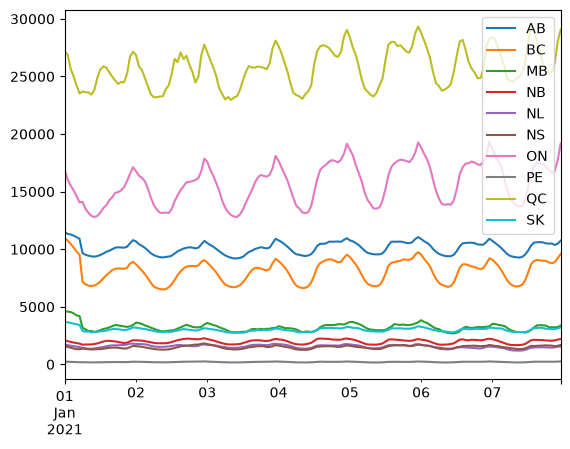

In [38]:
CODERS_load_profiles = convert_to_UTC(load_folder, f'loads_{REFERENCE_YEAR}_UTC.csv')
CODERS_load_profiles.loc[f'{REFERENCE_YEAR}-01-01':f'{REFERENCE_YEAR}-01-07'].plot()
CODERS_load_profiles.head()

In [39]:
end_use_demand_path = os.path.join(data_path, 'CER_data')
os.makedirs(end_use_demand_path, exist_ok=True)
download_and_unzip('https://www.cer-rec.gc.ca/open/energy/energyfutures2026/end-use-demand-2026.csv', os.path.join(end_use_demand_path, 'CEF2026_EUD.csv'), None)

end_use_demand = pd.read_csv(os.path.join(end_use_demand_path, 'CEF2026_EUD.csv'))
end_use_demand = end_use_demand[(end_use_demand.Scenario == LOAD_SCENARIO) & (end_use_demand.Variable == 'Electricity')]
end_use_demand.loc[:, 'Region'] = end_use_demand.Region.map(province_map)
end_use_demand.loc[:, 'Value'] = end_use_demand.loc[:, 'Value'].multiply(277800) # covert petajoules to MWh
end_use_demand.head()

c:\Users\ndematos\Desktop\pypsa_canada\PyPSA-Canada-National\data\CER_data\CEF2026_EUD.csv already exists. Skipping download.


,Scenario,Region,Variable,Year,Value,Sector
25438,Current Measures,AB,Electricity,2005,12241562.58,Commercial
25439,Current Measures,AB,Electricity,2005,36420441.18,Industrial
25440,Current Measures,AB,Electricity,2005,7688865.06,Residential
25441,Current Measures,AB,Electricity,2005,56501436.42,Total End-Use
25442,Current Measures,AB,Electricity,2005,150567.60,Transportation


disaggregate based on sector
scale based on total/year

In [40]:
cluster_data = clusters.copy().reset_index()
provinces = cluster_data.cluster.str[:2].unique()
all_profiles = pd.DataFrame()
for province in provinces:
    province_end_use = end_use_demand[end_use_demand.Region == province]
    prov_load_profile = CODERS_load_profiles.loc[:, province]
    prov_load_profile.name = province
    annual_profile = pd.DataFrame()
    for year in YEARS:
        year_end_use = province_end_use[province_end_use.Year == year]
        
        # Scaling values to match
        CODERS_demand = prov_load_profile.sum().round(0)
        CER_total_demand = year_end_use[year_end_use.Sector == 'Total End-Use'].Value.iloc[0].round(0)
        #print(f'{province} Annual ({year}) demand: CODERS = {CODERS_demand:,}), CER = ({CER_total_demand:,})')
        load_profile = prov_load_profile.multiply(CER_total_demand / CODERS_demand)

        # Splitting out industrial load
        industrial_fraction = year_end_use[year_end_use.Sector == 'Industrial'].Value.iloc[0].round(0) / CER_total_demand
        industrial_profile = load_profile.multiply(industrial_fraction)
        industrial_profile.name = f'{province}_Industrial'
        load_profile = load_profile.multiply(1-industrial_fraction)
        load_profile = pd.concat([load_profile, industrial_profile], axis=1)
        dates = pd.date_range(start=f'{year}-01-01 00:00:00', end=f'{year}-12-31 23:00:00', freq='h')
        dates = dates[~((dates.month == 2) & (dates.day == 29))]
        load_profile.index = dates
        
        annual_profile = pd.concat([annual_profile, load_profile])
    all_profiles = pd.concat([all_profiles, annual_profile], axis=1)
all_profiles.head()

,AB,AB_Industrial,BC,BC_Industrial,MB,MB_Industrial,NB,NB_Industrial,NL,NL_Industrial,NS,NS_Industrial,ON,ON_Industrial,PE,PE_Industrial,QC,QC_Industrial,SK,SK_Industrial
2025-01-01 00:00:00,4512.242704,6103.957648,6650.638649,4139.377049,3200.969387,904.990891,1315.459325,685.283958,1095.906491,533.094772,1166.947910,262.883733,12254.936558,5091.165520,174.046004,130.441888,16092.973983,13507.624095,1862.219236,1402.597378
2025-01-01 01:00:00,4440.122077,6006.396129,6491.483238,4040.318254,3203.062436,905.582646,1274.944698,664.178003,1061.480110,516.348340,1116.851661,251.598321,11656.355187,4842.492113,165.967920,124.387623,15930.071644,13370.892154,1849.065827,1392.690415
2025-01-01 02:00:00,4420.916040,5980.415072,6332.327828,3941.259458,3170.271337,896.311815,1236.329193,644.061390,1030.878881,501.462622,1062.335156,239.317136,11280.788963,4686.467656,158.624206,118.883746,15207.377631,12764.299546,1820.229506,1370.971303
2025-01-01 03:00:00,4382.503967,5928.452959,6143.519888,3823.744841,3090.037797,873.627868,1197.713688,623.944778,1007.290434,489.988214,1015.922455,228.861533,10977.866109,4560.622012,152.014864,113.930257,14803.972202,12425.701540,1789.875484,1348.109080
2025-01-01 04:00:00,4329.589377,5856.872497,5917.797575,3683.254610,2967.943281,839.108817,1168.593799,608.774873,980.514359,476.963211,973.930011,219.401702,10603.026319,4404.899344,145.405523,108.976767,14341.329559,12037.382830,1758.003761,1324.103746


In [ ]:
cluster_data = clusters.copy().reset_index()
provinces = cluster_data.cluster.str[:2].unique()
loads_p_set = {}
us_p_set = {}
loads = {}

for province in provinces:
    # Check for CER load profile, if enabled
    load_path = os.path.join(path, 'data', 'CER_data', f'{scenario_map[LOAD_SCENARIO]}')
    load_file = os.path.join(load_path, f'{province}_{scenario_map[LOAD_SCENARIO]}.csv')
    
    if not os.path.exists(load_file) or not CER_DEMAND:
        print(f'Using CODERS demand for {province}')
        load_profile = all_profiles[[province, f'{province}_Industrial']]
        load_profile = load_profile.reset_index().rename(columns={'index':'LocalTime', province:'Non-Industrial', f'{province}_Industrial':'Industrial'})
    else:
        print(f'Using CER demand for {province}')
        load_profile = pd.read_csv(load_file)
        # Creation of a Local Time column from Year and LocalHour index
        load_profile['LocalHour'] = load_profile['LocalHour'].astype(int)
        load_profile['LocalTime'] = pd.to_datetime(load_profile['Year'].astype(str), format='%Y') + pd.to_timedelta(load_profile['LocalHour'] - 1, unit='h')
        load_profile['Non-Industrial'] = load_profile['Total'].subtract(load_profile['Industrial'])
    
    prov_clusters = cluster_data[cluster_data.cluster.str.contains(province)]['cluster'].to_list()

    for cluster in prov_clusters:
        load_key = cluster + '_load'
        loads[load_key] = cluster

        if f'{cluster}_US_trade' in us_provincial_load_all_years.columns:
            loads[f'{cluster}_US_trade'] = cluster

        ind_frac = load_split.loc[cluster, 'ind_load']
        pop_frac = load_split.loc[cluster, 'pop_load']
        
        yearly_loads = []
        yearly_transfers = []
        for year in YEARS:
            load_profile_year = load_profile[load_profile['LocalTime'].dt.year == year].reset_index(drop=True)
            ind_load = load_profile_year.Industrial * ind_frac if ind_frac > 0 else 0
            pop_load = load_profile_year['Non-Industrial'] * pop_frac if pop_frac > 0 else 0

            total_load = ind_load + pop_load
            yearly_loads.append(total_load)

        loads_p_set[load_key] = pd.concat(yearly_loads, ignore_index=True)

        
loads_p_set = pd.DataFrame.from_dict(loads_p_set)
# Create indexes
date_ranges = [
    pd.date_range(start=f'{year}-01-01', end=f'{year}-12-31 23:00', freq='h') 
    for year in YEARS
]
date_index = pd.DatetimeIndex(sorted(pd.concat([pd.Series(dates) for dates in date_ranges])))
# Removing leap days
date_index = date_index[~((date_index.month == 2) & (date_index.day == 29))]
loads_p_set.index = date_index

loads_p_set = pd.concat([loads_p_set, us_provincial_load_all_years], axis=1).round(2)

Using CER demand for AB
Using CER demand for BC
Using CER demand for MB
Using CER demand for NB
Using CER demand for NL
Using CER demand for NS
Using CER demand for ON
Using CER demand for PE
Using CER demand for QC
Using CER demand for SK


In [42]:
loads_p_set.to_csv(os.path.join(results_path, f'loads_forecast_{scenario_map[LOAD_SCENARIO]}.csv'))
all_loads = pd.DataFrame.from_dict(loads, orient='index', columns=['bus'])
all_loads.index.name = 'name'

all_loads.to_csv(os.path.join(results_path, 'loads.csv'))